# Colorectal Cancer Risk & Survival Prediction

## Objective
The goal of this project is to predict the **survival status** of colorectal cancer patients based on their demographics, medical history, and lifestyle factors.

## Dataset Overview
The dataset contains records of **colorectal cancer patients**, with features related to risk factors, treatment, and outcomes.

## Instructions
1. **Data Exploration**: Load and examine the dataset.
2. **Data Preprocessing**: Handle missing values, encode categorical variables, and normalize numerical features.
3. **Feature Selection**: Identify important predictors for survival.
4. **Model Training**: Train a classification model to predict survival status.
5. **Evaluation**: Assess model performance using accuracy and classification reports.

In [25]:

# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score


In [26]:

# Load the dataset
df = pd.read_csv('colorectal_cancer_prediction.csv')
df.head()

# Display basic information about the dataset
df.info()
df.columns



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89945 entries, 0 to 89944
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               89945 non-null  int64  
 1   Age                      89945 non-null  int64  
 2   Gender                   89945 non-null  object 
 3   Race                     89945 non-null  object 
 4   Region                   89945 non-null  object 
 5   Urban_or_Rural           89945 non-null  object 
 6   Socioeconomic_Status     89945 non-null  object 
 7   Family_History           89945 non-null  object 
 8   Previous_Cancer_History  89945 non-null  object 
 9   Stage_at_Diagnosis       89945 non-null  object 
 10  Tumor_Aggressiveness     89945 non-null  object 
 11  Colonoscopy_Access       89945 non-null  object 
 12  Screening_Regularity     89945 non-null  object 
 13  Diet_Type                89945 non-null  object 
 14  BMI                   

Index(['Patient_ID', 'Age', 'Gender', 'Race', 'Region', 'Urban_or_Rural',
       'Socioeconomic_Status', 'Family_History', 'Previous_Cancer_History',
       'Stage_at_Diagnosis', 'Tumor_Aggressiveness', 'Colonoscopy_Access',
       'Screening_Regularity', 'Diet_Type', 'BMI', 'Physical_Activity_Level',
       'Smoking_Status', 'Alcohol_Consumption', 'Red_Meat_Consumption',
       'Fiber_Consumption', 'Insurance_Coverage', 'Time_to_Diagnosis',
       'Treatment_Access', 'Chemotherapy_Received', 'Radiotherapy_Received',
       'Surgery_Received', 'Follow_Up_Adherence', 'Survival_Status',
       'Recurrence', 'Time_to_Recurrence'],
      dtype='object')

## Exploratory Data Analysis (EDA)
- Check for missing values
- Visualize key distributions
- Identify correlations between features

In [27]:
# Check for missing values
df.isnull().sum()

,0
Patient_ID,0
Age,0
Gender,0
Race,0
Region,0
Urban_or_Rural,0
Socioeconomic_Status,0
Family_History,0
Previous_Cancer_History,0
Stage_at_Diagnosis,0


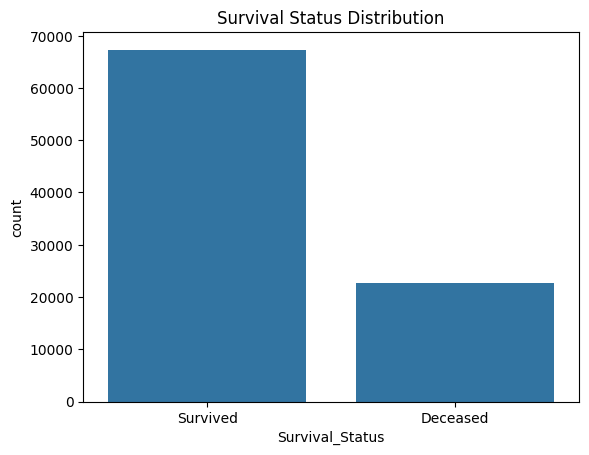

In [28]:
# Visualize survival status distribution

sns.countplot(x='Survival_Status', data=df)
plt.title("Survival Status Distribution")
plt.show()


# Survival Insights
* The majority of patients in the dataset have survived.
* The dataset is slightly imbalanced, with more “Survived” cases than “Deceased”.
* This imbalance may influence model predictions.



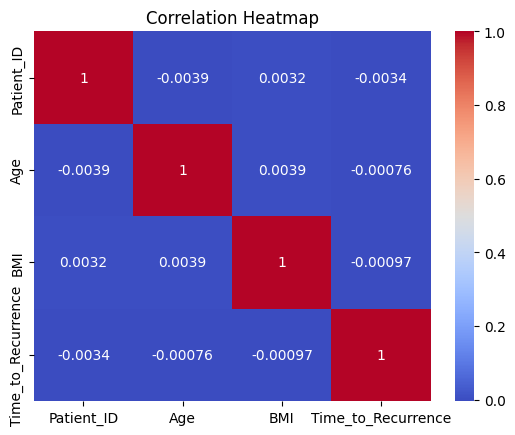

In [29]:
# Correlation heatmap (numerical features only)
numeric_df = df.select_dtypes(include=['int64','float64'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Correlation Insights
* The correlation heatmap shows weak relationships between numerical features.
* Most values are close to zero, indicating no strong correlation.
* Features like Age and BMI do not significantly influence each other.
* Patient_ID is not meaningful for analysis and can be ignored.

## Data Preprocessing
- Handle missing values
- Encode categorical variables
- Normalize numerical features

In [ ]:
# Drop unnecessary columns (e.g., Patient ID if present)
df = df.drop('Patient_ID', axis=1)

In [30]:

# Encode categorical variables
df_encoded = pd.get_dummies(df, drop_first=True)

# Define features and target variable
  # Adjust target column name as needed
X = df_encoded.drop('Survival_Status_Survived', axis=1)
y = df_encoded['Survival_Status_Survived']

# Split into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


## Model Training
Train a **Logistic Regression** model to predict patient survival.

In [32]:

# Train a Logistic Regression model
model = LogisticRegression(max_iter=2000, class_weight='balanced')
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model evaluation
# print("Accuracy:", accuracy_score(y_test, y_pred))
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

# print("Classification Report:\n", classification_report(y_test, y_pred))
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))


Accuracy: 0.5039190616487854
              precision    recall  f1-score   support

       False       0.25      0.49      0.33      4561
        True       0.75      0.51      0.60     13428

    accuracy                           0.50     17989
   macro avg       0.50      0.50      0.47     17989
weighted avg       0.62      0.50      0.54     17989

